In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("HR-Employee-Attrition.csv")

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.shape

(1470, 35)

In [7]:
df.columns=df.columns.str.lower()

In [8]:
df=df.rename(columns=({"businesstravel":"business_travel","dailyrate":"daily_rate","distancefromhome":"distance_from_home","educationfield":"education_field","employeecount":"employee_count","employeenumber":"employee_number","relationshipsatisfaction":"relationship_satisfaction","standardhours":"standard_hours","stockoptionlevel":"stock_option_level","totalworkingyears":"total_working_years","trainingtimeslastyear":"training_times_last_year","worklifebalance":"work_life_balance","yearsatcompany":"years_at_company","yearsincurrentrole":"years_in_current_role","yearssincelastpromotion":"years_since_last_promotion","yearswithcurrmanager":"years_with_curr_manager"}))

In [9]:
df=df.drop(columns=["employee_count","employee_number","standard_hours"])

In [10]:
df["age"].unique()

array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
       24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
       58, 20, 25, 19, 57, 52, 47, 18, 60])

In [11]:
df["age_group"]=pd.cut(
    df["age"],
    bins=[18,25,35,45,60],
    labels=["18-25","26-35","36-45","46+"]
)

In [12]:
df["experience_category"]=pd.cut(
    df["total_working_years"],
    bins=[0,5,10,20,50],
    labels=["Beginner","Intermediate","Experienced","Senior"]
)
    

In [13]:
df["promotion_status"]=df["years_since_last_promotion"].apply(lambda x:"Recently_promoted" if x<=2 else " Long Time no Promotion")

In [14]:
df.isnull().sum()

age                            0
attrition                      0
business_travel                0
daily_rate                     0
department                     0
distance_from_home             0
education                      0
education_field                0
environmentsatisfaction        0
gender                         0
hourlyrate                     0
jobinvolvement                 0
joblevel                       0
jobrole                        0
jobsatisfaction                0
maritalstatus                  0
monthlyincome                  0
monthlyrate                    0
numcompaniesworked             0
over18                         0
overtime                       0
percentsalaryhike              0
performancerating              0
relationship_satisfaction      0
stock_option_level             0
total_working_years            0
training_times_last_year       0
work_life_balance              0
years_at_company               0
years_in_current_role          0
years_sinc

In [15]:
df["experience_category"].unique()

['Intermediate', 'Experienced', 'Beginner', 'Senior', NaN]
Categories (4, object): ['Beginner' < 'Intermediate' < 'Experienced' < 'Senior']

In [16]:
df["experience_category"]=df["experience_category"].astype(str).fillna("Unknown").astype('category')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         1470 non-null   int64   
 1   attrition                   1470 non-null   object  
 2   business_travel             1470 non-null   object  
 3   daily_rate                  1470 non-null   int64   
 4   department                  1470 non-null   object  
 5   distance_from_home          1470 non-null   int64   
 6   education                   1470 non-null   int64   
 7   education_field             1470 non-null   object  
 8   environmentsatisfaction     1470 non-null   int64   
 9   gender                      1470 non-null   object  
 10  hourlyrate                  1470 non-null   int64   
 11  jobinvolvement              1470 non-null   int64   
 12  joblevel                    1470 non-null   int64   
 13  jobrole           

In [18]:
df.describe()

,age,daily_rate,distance_from_home,education,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,...,performancerating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [19]:
df["attrition"].value_counts()

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [20]:
df["department"].value_counts()

department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [21]:
df["age_group"].value_counts()

age_group
26-35    606
36-45    468
46+      273
18-25    115
Name: count, dtype: int64

In [22]:
df.groupby("business_travel")["years_at_company"].max()

business_travel
Non-Travel           33
Travel_Frequently    32
Travel_Rarely        40
Name: years_at_company, dtype: int64

In [23]:
df.nlargest(10,"daily_rate")[["daily_rate","gender"]]

,daily_rate,gender
427,1499,Female
986,1498,Male
155,1496,Male
1056,1496,Male
471,1495,Female
1044,1495,Male
1202,1495,Female
785,1492,Male
408,1490,Female
416,1490,Male


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Business Travel')

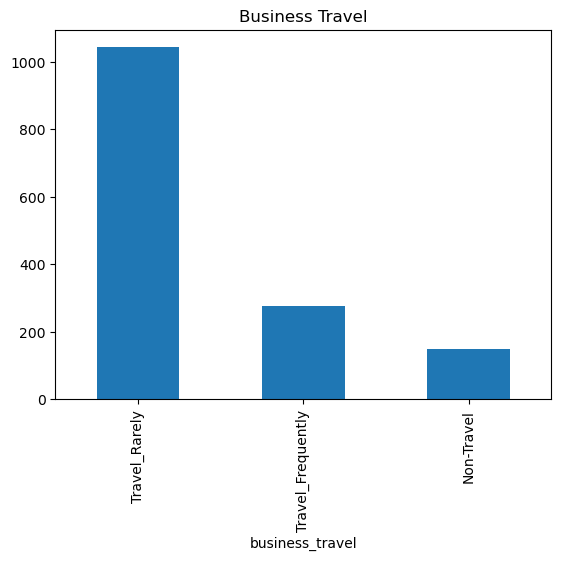

In [25]:
df["business_travel"].value_counts().plot(kind="bar")
plt.title("Business Travel")

Text(0.5, 1.0, 'Attrition Distribution')

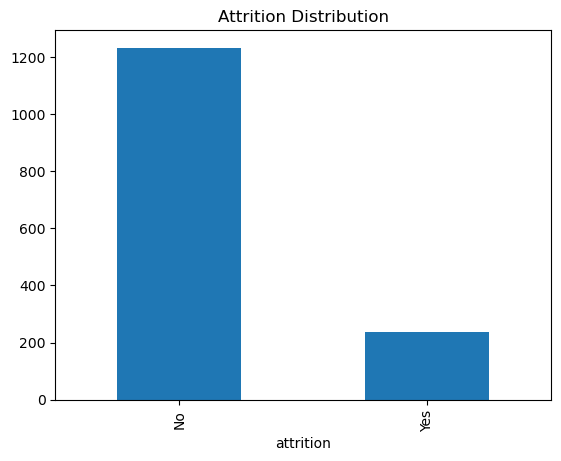

In [26]:
df["attrition"].value_counts().plot(kind="bar")
plt.title("Attrition Distribution")

<Axes: xlabel='department'>

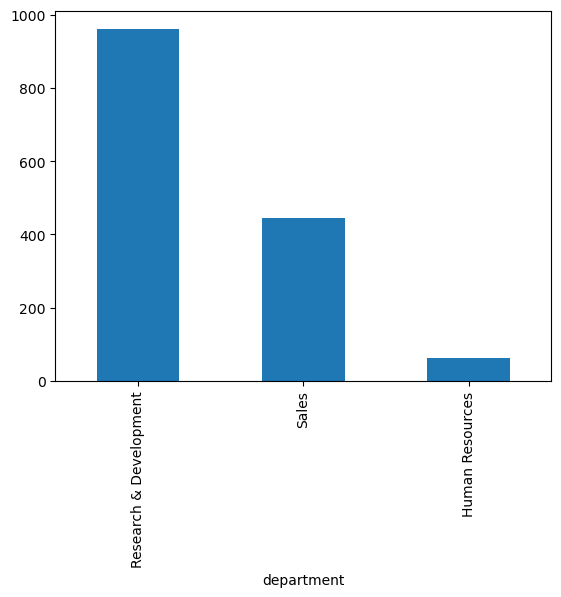

In [27]:
df["department"].value_counts().plot(kind="bar")

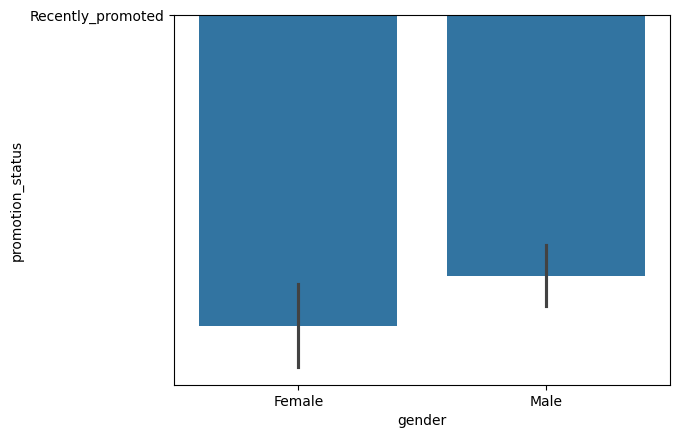

In [28]:
sns.barplot(x="gender",y="promotion_status",data=df)
plt.show()

In [29]:
df.corr(numeric_only=True)

,age,daily_rate,distance_from_home,education,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,...,performancerating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
daily_rate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
distance_from_home,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
environmentsatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
hourlyrate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
jobinvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
joblevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
jobsatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
monthlyincome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


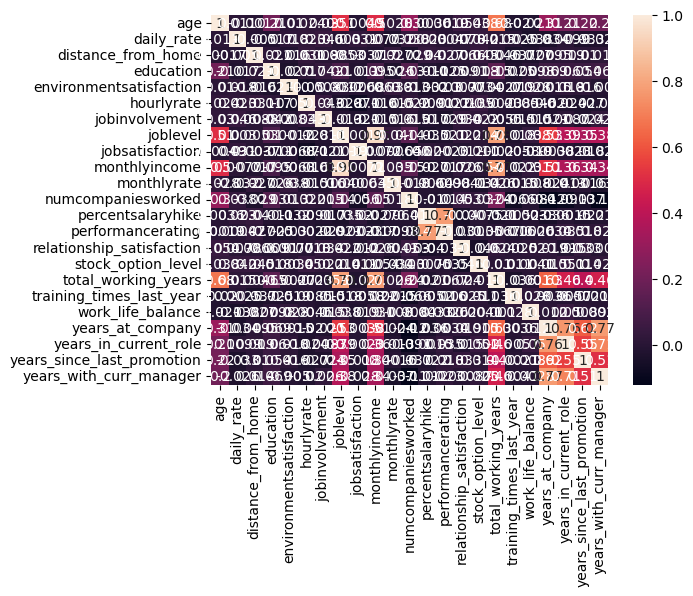

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [31]:
df.to_excel("hr.analytics_cleaned.xlsx",index=False)

In [32]:
df=pd.read_excel("hr.analytics_cleaned.xlsx")

In [33]:
df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,environmentsatisfaction,gender,...,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,age_group,experience_category,promotion_status
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,8,0,1,6,4,0,5,36-45,Intermediate,Recently_promoted
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,10,3,3,10,7,1,7,46+,Intermediate,Recently_promoted
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,7,3,3,0,0,0,0,36-45,Intermediate,Recently_promoted
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,8,3,3,8,7,3,0,26-35,Intermediate,Long Time no Promotion
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,6,3,3,2,2,2,2,26-35,Intermediate,Recently_promoted


In [34]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [35]:
from sqlalchemy import create_engine
username = "postgres"
password = "satyam123"
host = "localhost"
port= "5432"
database = "hr_analytics"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

table_name = "hr_data"
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data Successfully loaded into table '{table_name}' in database '{database}'.")

Data Successfully loaded into table 'hr_data' in database 'hr_analytics'.
